# XGBoost


## 1.1 Principles of XGBoost
The XGBoost algorithm can be considered one of the most powerful methods in ensemble learning. To some extent, XGBoost can be viewed as an improved version of the Gradient Boosting Decision Tree (GBDT) algorithm. In essence, both methods are based on the idea of boosting, where models are trained sequentially by fitting the residuals of previous models.


Initial decision tree:
if Monthly Income < 20,000:
    if Age < 25:
        Prediction: 10,000   (Sample A residual = -2,000)
    else:
        Prediction: 20,000   (Sample C residual = 5,000)
else:
    Prediction: 35,000       (Samples B, D; 
                              B residual = -5,000, 
                              D residual = 5,000)

The predictions of the initial decision tree are not perfectly accurate, which leads to residuals (errors). 

Therefore, a new decision tree is trained to fit these residuals. This new tree will, in turn, produce its own residuals, and another tree is constructed to fit these new residuals.

This process continues iteratively, with each new tree correcting the errors of the previous model, until a predefined stopping condition is satisfied.

## 1.2 Mathematical Principles of XGBoost

As an efficient implementation of GBDT, XGBoost improves the method in the following two aspects:

1. Optimization of the Algorithm Itself

The loss function in XGBoost includes not only the original loss term but also a regularization term. This helps prevent overfitting and improves generalization ability. Moreover, XGBoost applies a second-order Taylor expansion to the loss function. In contrast, GBDT typically uses only the first-order approximation (i.e., the negative gradient). The use of second-order information (both gradient and Hessian) makes the optimization more accurate and efficient.

2. Optimization of Computational Efficiency

XGBoost improves computational performance by parallelizing parts of the tree construction process. For each weak learner (e.g., a decision tree), it performs efficient searches to determine the best feature and split point for node partitioning, significantly speeding up training.

Among these, the optimization of the algorithm itself is both the most important and the most challenging part, as the mathematical derivation is quite complex. Those interested are encouraged to explore it further.

## 1.3 Simple Code Implementation of XGBoost

XGBoost can be used for both classification and regression tasks:

Classification model: XGBClassifier
Regression model: XGBRegressor
To install XGBoost, simply run:pip install xgboost

In [1]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 6.3 MB/s  0:00:00 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
from xgboost import XGBClassifier

In [ ]:
# If you don't know how to use it, you can ask.
XGBClassifier?

Init signature:
XGBClassifier(
    *,
    objective: Union[str, xgboost.sklearn._SklObjWProto, Callable[[Any, Any], Tuple[numpy.ndarray, numpy.ndarray]], NoneType] = 'binary:logistic',
    **kwargs: Any,
) -> None
Docstring:     
Implementation of the scikit-learn API for XGBoost classification.
See :doc:`/python/sklearn_estimator` for more information.

Parameters
----------

    n_estimators : Optional[int]
        Number of boosting rounds.

    max_depth :  typing.Optional[int]

        Maximum tree depth for base learners.

    max_leaves : typing.Optional[int]

        Maximum number of leaves; 0 indicates no limit.

    max_bin : typing.Optional[int]

        If using histogram-based algorithm, maximum number of bins per feature

    grow_policy : typing.Optional[str]

        Tree growing policy.

        - depthwise: Favors splitting at nodes closest to the node,
        - lossguide: Favors splitting at nodes with highest loss change.

    learning_rate : typing.Optional[float

In [4]:
# XGBoost Classification Model
from xgboost import XGBClassifier

import numpy as np
# import data
x = np.array([[1,2],[3,4],[5,6],[7,8],[9,10]])
y = [0, 0, 1, 1, 1]

# Set up model
model = XGBClassifier()

# Model fitting
model.fit(x, y)

# Model makes predictions
print(model.predict([[10,10]]))

[1]


In [5]:
# XGBoost Regression Model
from xgboost import XGBRegressor

import numpy as np

# import data
x = np.array([[1,2],[3,4],[5,6],[7,8],[9,10]])
y = [1, 2, 3, 4, 5]

# Set up model
model = XGBRegressor()

# Model fitting
model.fit(x, y)

# Model prediction
print(model.predict([[5, 5], [1,1], [10, 10]]))

[2.9999917 1.0010211 4.998999 ]


## 1.4 XGBoost case study 1

### 1.4.1 Case study background

Credit card fraud typically occurs when a cardholder’s information is stolen by criminals and used to create a duplicate card for unauthorized transactions, or when a credit card is fraudulently obtained, activated, and used by someone else. Once such fraud occurs, both the cardholder and the bank may suffer financial losses.

### 1.4.2 Model build up

In [1]:
# 1. Import data
import pandas as pd
df = pd.read_excel('Credit card transaction data.xlsx')
df.head()

,Number of Device Changes,Number of Payment Failures,Number of IP Changes,Number of IP Country Changes,Transaction Amount,Fraud Label
0,0,11,3,5,28836,1
1,5,6,1,4,21966,1
2,6,2,0,0,18199,1
3,5,8,2,2,24803,1
4,7,10,5,0,26277,1


A total of 1,000 credit card transaction records are used in this dataset. The feature variables include the number of device changes by the customer, the number of payment failures prior to the current transaction, the number of IP address changes, the number of IP country changes, and the transaction amount.

The target variable indicates whether the current transaction is fraudulent. If the transaction is caused by credit card fraud, it is labeled as 1 (fraud); otherwise, it is labeled as 0 (normal transaction).

We can also examine how many samples are fraudulent and how many are non-fraudulent.

In [7]:
df[df['Fraud Label']==1].count()

Number of Device Changes        400
Number of Payment Failures      400
Number of IP Changes            400
Number of IP Country Changes    400
Transaction Amount              400
Fraud Label                     400
dtype: int64

In [ ]:
# There are 600 normal transactions and 400 fraudulent transactions.
sum(df['Fraud Label']==0)

600

In [9]:
# 2. Extract feature variables
x = df.drop(columns='Fraud Label')
y = df['Fraud Label']

# 3. Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=123)

In [10]:
# 4. Model training and construction
from xgboost import XGBClassifier

# Set the maximum number of iterations for the weak learners (i.e., the number of weak learners), and set the learning rate (shrinkage factor) to 0.05; all other parameters remain at their default values.
clf = XGBClassifier(n_estimators=100, learning_rate=0.05)
clf.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### 1.4.3 Model prediction and evaluation

In [11]:
y_pred = clf.predict(x_test)
y_pred

array([0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 1])

In [12]:
# Summary
a = pd.DataFrame()
a['Prediction values'] = list(y_pred)
a['Actual values'] = list(y_test)
a.head()

,Prediction values,Actual values
0,0,1
1,1,1
2,1,1
3,0,0
4,0,1


In [13]:
# Calculate prediction accuracy
from sklearn.metrics import accuracy_score
score = accuracy_score(y_pred, y_test)
score

0.875

In [14]:
# Use the model’s built-in function to evaluate accuracy.
clf.score(x_test, y_test)

0.875

The XGBoost classification model does not directly predict exact class labels (0 or 1) in essence; instead, it predicts the probability that a sample belongs to each class. We can use the predict_proba() function to view the predicted probabilities for each class.

In [15]:
y_pred_proba = clf.predict_proba(x_test)
# Here we can see the probability of being classified as 0 (non-fraud).
y_pred_proba[:,0]

array([0.8706477 , 0.02221072, 0.00936866, 0.8994155 , 0.8518455 ,
       0.93297535, 0.00971675, 0.90748745, 0.86159945, 0.87287164,
       0.15223044, 0.00940514, 0.01373512, 0.01198894, 0.01550424,
       0.8573186 , 0.8326417 , 0.78549093, 0.92615795, 0.8947163 ,
       0.01323378, 0.00994408, 0.00994408, 0.82442105, 0.8799035 ,
       0.8543282 , 0.92568034, 0.8919562 , 0.9168415 , 0.02029115,
       0.871334  , 0.02107739, 0.68075264, 0.0148024 , 0.90868235,
       0.89011   , 0.02397883, 0.00940514, 0.14062983, 0.9110238 ,
       0.8644429 , 0.01468736, 0.82989633, 0.85571754, 0.88975286,
       0.92377746, 0.00994408, 0.89823186, 0.88565093, 0.90849286,
       0.00936866, 0.8740642 , 0.8967611 , 0.9012506 , 0.00994408,
       0.01191634, 0.9306531 , 0.01181191, 0.90339136, 0.9209061 ,
       0.9044288 , 0.9354427 , 0.01366854, 0.87835824, 0.01027691,
       0.9074845 , 0.89388657, 0.89920336, 0.9108453 , 0.11090207,
       0.01191634, 0.8370256 , 0.9101904 , 0.9191222 , 0.79878

In [16]:
# The first column corresponds to class 0, and the second column corresponds to class 1.
y_pred_proba.shape

(200, 2)

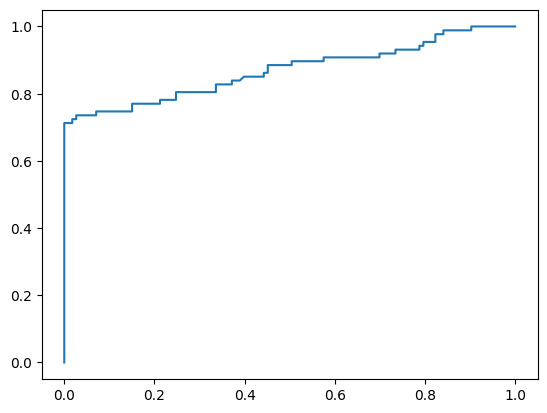

In [17]:
# Plot the ROC curve to evaluate the model’s predictive performance.
from sklearn.metrics import roc_curve
fpr, tpr, thres = roc_curve(y_test, y_pred_proba[:, 1])

import matplotlib.pyplot as plt
plt.plot(fpr, tpr)
plt.show()

In [18]:
# Calculate the model’s AUC value: it is above 0.868, indicating that the predictive performance is relatively good.
from sklearn.metrics import roc_auc_score
score = roc_auc_score(y_test, y_pred_proba[:, 1])
score

0.8690367205777643

In [19]:
# Examine the feature importance.
features = x.columns
importances = clf.feature_importances_
importances_df = pd.DataFrame()
importances_df['Feature name'] = features
importances_df['Feature importance'] = importances
importances_df.sort_values('Feature importance', ascending=False)

,Feature name,Feature importance
0,Number of Device Changes,0.395957
3,Number of IP Country Changes,0.348460
1,Number of Payment Failures,0.188594
2,Number of IP Changes,0.042056
4,Transaction Amount,0.024933


It can be observed that the most important feature is “number of device changes”, while the least important feature is “transaction amount.”

Note that these results are specific to this dataset. If the data changes or the model parameters are adjusted, the feature importance rankings may also change. 

Therefore, the following interpretation is only illustrative:

A high number of payment failures may indicate that a fraudster is repeatedly attempting unauthorized transactions, so this feature tends to have relatively high importance.

For the top features (e.g., device changes and IP country changes), under normal usage, the frequency of changing devices or IP countries is usually low. If these values are unusually high, it may suggest fraudulent activity caused by stolen credit card information.

In this case, the number of IP changes and transaction amount play a relatively smaller role in distinguishing between fraudulent and non-fraudulent transactions.

### 1.4.4 Model Parameter Tuning

The XGBoost model has many parameters. Here we focus on a few key ones:

max_depth: The maximum depth of each weak learner (decision tree). Default is 3.

n_estimators: The number of weak learners (i.e., the maximum number of iterations). Default is 100.

learning_rate: The learning rate, also known as the shrinkage factor for each weak learner. Its value ranges from (0, 1]. A smaller value means that more iterations (more trees) are needed to achieve good performance. The default value is 0.1. Typically, n_estimators and learning_rate should be tuned together, as they jointly determine the model’s fitting performance.

In [25]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
parameters = {'max_depth': [1, 3, 5],
             'n_estimators': [50, 100, 150],
             'learning_rate': [0.01, 0.05, 0.1, 0.2]}

clf = XGBClassifier()
grid_search = GridSearchCV(clf, parameters, scoring='roc_auc', cv=5)

In [26]:
import pandas as pd
# 1. Import data
df = pd.read_excel('Credit card transaction data.xlsx')

# 2. Extract feature variables
x = df.drop(columns='Fraud Label')
y = df['Fraud Label']

#3. Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=123)

# 4. Training
grid_search.fit(x_train, y_train)

# 5. Output the optimal parameters
grid_search.best_params_

{'learning_rate': 0.05, 'max_depth': 1, 'n_estimators': 100}

It can be observed that with the parameter setting {'learning_rate': 0.05, 'max_depth': 1, 'n_estimators': 100} the model achieves the best predictive performance for this dataset.

Specifically:

The maximum depth of each weak learner (decision tree) is set to 1

The number of weak learners (iterations) is set to 100

The learning rate (shrinkage factor) is set to 0.05

This combination yields the best results for this case (though better configurations may still exist).


In [27]:
# Train the model using the newly obtained parameters above
clf = XGBClassifier(max_depth=1, n_estimators=100, learning_rate=0.05)
clf.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [28]:
# Check the AUC
y_pred_proba = clf.predict_proba(x_test)
from sklearn.metrics import roc_auc_score
score = roc_auc_score(y_test, y_pred_proba[:, 1])

In [29]:
# This result is slightly lower than the pre-tuning value of 0.866.
score

0.8563218390804598

Why does this happen? The performance after tuning is actually worse.
In general, this situation is relatively uncommon. It may be due to the small dataset size, or because cross-validation is used in this case.

Specifically, the original dataset is divided into K folds (here, cv = 5, i.e., 5 folds). Then:
In each iteration, K−1 folds are used as the training set
The remaining 1 fold is used as a validation set
The model is trained K times, resulting in K ROC curves and K AUC values
The average AUC is computed, and the parameter combination that yields the highest average AUC is selected as the optimal one

It is important to note that, in this case, the AUC is computed based on the training data, where only $\frac{1}{K}$ of it is treated as a validation set. This validation set is not the true test set (y_test).

This explains why the performance after tuning may appear worse than before tuning when evaluated on the actual test set.

For the XGBoost regression model, most parameters are the same as those of the XGBoost classification model, with only a few differences. For example, the objective parameter is set to "reg:linear" for regression problems, "binary:logistic" for binary classification, and "multi:softmax" for multi-class classification.
However, when using the XGBoost regression model, this parameter is automatically set, so there is no need to adjust it manually.

## 1.5 XGBoost case study 2

### 1.5.1 Background

To reduce the rate of non-performing loans, ensure the safety of funds, and improve risk control, financial institutions such as banks build credit scoring models based on customers’ credit history data.

Based on a customer’s credit score, the likelihood of timely repayment can be estimated, which helps determine whether to grant a loan, as well as the loan amount and interest rate.

### 1.5.2 First, use a multiple linear regression model

In [1]:
# 1. Import data
import pandas as pd
df = pd.read_excel('Credit scoring model.xlsx')
df.head()

,Monthly Income,Age,Gender,Historical Credit Limit,Number of Past Defaults,Credit Score
0,7783,29,0,32274,3,73
1,7836,40,1,6681,4,72
2,6398,25,0,26038,2,74
3,6483,23,1,24584,4,65
4,5167,23,1,6710,3,73


There are 5 feature variables here, and the target variable is ‘Credit Score’, with a value range of 0–100.

In [3]:
# 2. Split the dataset into features (X) and target (y)
x = df.drop(columns='Credit Score')
y = df['Credit Score']

# 3. Build model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x, y)

# 4. Regression model
print('Parameters'+str(model.coef_))
print('Constant k0 '+str(model.intercept_))

Parameters[ 5.58658996e-04  1.62842002e-01  2.18430276e-01  6.69996665e-05
 -1.51063940e+00]
Constant k0 67.16686603853383


The multiple linear regression model is: $$y = 67.17 + 0.000557x_1 + 0.163x_2 + 0.218x_3 + 0.00007x_4 - 1.51x_5$$

In [4]:
# 5. Performance assessment
import statsmodels.api as sm
x2 = sm.add_constant(x)        # An intercept term is added to X
est = sm.OLS(y, x2).fit()      # OLS is the “Least Squares Method”
print(est.summary())

                            OLS Regression Results                            
Dep. Variable:           Credit Score   R-squared:                       0.629
Model:                            OLS   Adj. R-squared:                  0.628
Method:                 Least Squares   F-statistic:                     337.6
Date:                Mon, 20 Apr 2026   Prob (F-statistic):          2.32e-211
Time:                        19:21:29   Log-Likelihood:                -2969.8
No. Observations:                1000   AIC:                             5952.
Df Residuals:                     994   BIC:                             5981.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

From the summary results, the overall R-squared of the model is 0.629, and the adjusted R-squared is 0.628, indicating a moderate overall fit, which may be due to the relatively small sample size.

Looking at the p-values, most feature variables have p-values less than 0.05, suggesting that they are significantly associated with the target variable ‘Credit Score’. However, the p-value of the feature variable ‘Gender’ is 0.466, indicating that it is not significantly related to the target variable. This is also consistent with general expectations. Therefore, the feature variable ‘Gender’ can be excluded from the multiple linear regression model.

### 1.5.3 Then use a GBDT regression model

In [6]:
# 1. Import data
import pandas as pd
df = pd.read_excel('Credit scoring model.xlsx')

# 2. Split the dataset into features (X) and target (y)
x = df.drop(columns='Credit Score')
y = df['Credit Score']

# 3. Split training and test datasets
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=123)

# 4. Model training
from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor()  # Use default parameters
model.fit(x_train, y_train)

# 5. Prediction and performance assessment
y_pred = model.predict(x_test)
print(y_pred[:10]) # Check the first 10 data samples

# 6. Make a summary of the predicted values and actual values
a = pd.DataFrame()
a['Predicted values'] = list(y_pred)
a['Actual values'] = list(y_test)

# 7. Check R_square
from sklearn.metrics import r2_score
r2 = r2_score(y_test, model.predict(x_test))
print(r2)

# Print accuracy score
print(model.score(x_test, y_test))

[70.77631652 71.40032104 73.73465155 84.52533945 71.09188294 84.9327599
 73.72232388 83.44560704 82.61221486 84.86927209]
0.6756872963457696
0.6756872963457696


The R-squared of the multiple linear regression is 0.629, while the R-squared of the GBDT regression is 0.676, indicating an improvement over the previous result

### 1.5.4 Use XGBoost

In [7]:
# 1. Import data
import pandas as pd
df = pd.read_excel('Credit scoring model.xlsx')

# 2. Split the dataset into features (X) and target (y)
x = df.drop(columns='Credit Score')
y = df['Credit Score']

# 3. Split training and test datasets
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=123)

# 4. Model training
from xgboost import XGBRegressor
model = XGBRegressor()
model.fit(x_train, y_train)

# 5. Prediction and performance assessment
y_pred = model.predict(x_test)
a = pd.DataFrame()
a['Predicted values'] = list(y_pred)
a['Actual values'] = list(y_test)

from sklearn.metrics import r2_score
r2 = r2_score(y_test, model.predict(x_test))
print(r2)
print(model.score(x_test, y_test))

# 6. Check feature importance
# Feature name
features = x.columns
# Feature importance
importances = model.feature_importances_
# Merge and display in descending order
importances_df = pd.DataFrame()
importances_df['Feature name'] = features
importances_df['Feature importance'] = importances
importances_df.sort_values('Feature importance', ascending=False)

0.5706756114959717
0.5706756114959717


,Feature name,Feature importance
4,Number of Past Defaults,0.542783
0,Monthly Income,0.243293
3,Historical Credit Limit,0.110344
1,Age,0.058815
2,Gender,0.044765


The R-squared is lower than before.
Why is that? Let’s try tuning the parameters

In [8]:
# 7. Parameter tuning 
from sklearn.model_selection import GridSearchCV
parameters = {'max_depth': [1, 3, 5, 7, 9],
             'n_estimators': [50, 100, 150, 200],
             'learning_rate': [0.01, 0.05, 0.1, 0.2]}
clf = XGBRegressor()

grid_search = GridSearchCV(clf, parameters, scoring='r2', cv=5) 
# Import data
grid_search.fit(x_train, y_train)
# Output optimal parameters
grid_search.best_params_

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}

Note that for the scoring metric, we choose R² (r2) because this is a regression problem, rather than classification metrics such as accuracy or the ROC curve AUC (‘roc_auc’).

In [10]:
# 1. Import data
import pandas as pd
df = pd.read_excel('Credit scoring model.xlsx')

# 2. Split the dataset into features (X) and target (y)
x = df.drop(columns='Credit Score')
y = df['Credit Score']

# 3. Split training and test datasets
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=123)

# 4. Model training
from xgboost import XGBRegressor
model = XGBRegressor(max_depth=3, n_estimators=50)
model.fit(x_train, y_train)

# 5. Prediction and performance assessment
y_pred = model.predict(x_test)
a = pd.DataFrame()
a['Predicted values'] = list(y_pred)
a['Actual values'] = list(y_test)

from sklearn.metrics import r2_score
r2 = r2_score(y_test, model.predict(x_test))
print(r2)
print(model.score(x_test, y_test))

# 6. Check feature importance
# Feature name
features = x.columns
# Feature importance
importances = model.feature_importances_
# Merge and display in descending order
importances_df = pd.DataFrame()
importances_df['Feature name'] = features
importances_df['Feature importance'] = importances
importances_df.sort_values('Feature importance', ascending=False)

0.6614603996276855
0.6614603996276855


,Feature name,Feature importance
4,Number of Past Defaults,0.496419
0,Monthly Income,0.292144
3,Historical Credit Limit,0.140641
1,Age,0.045961
2,Gender,0.024835


Model Comparison & Notes
After tuning, performance is slightly improved, but still worse than GBDT regression

XGBoost: Key Characteristics

$\bullet$ Less data preprocessing required

$\bullet$ Handles missing values automatically

$\bullet$ Tree-based model advantages

No need for:

$\bullet$ Standardization / normalization

$\bullet$ Log transformation

$\bullet$ Discretization

$\bullet$ Multicollinearity handling

$\bullet$ Robust to multicollinearity

Important Takeaway

$\bullet$ XGBoost reduces feature engineering effort

$\bullet$ But feature engineering is still essential
